# Styles playground

Experiments with a hand-built `Styler` — design in [styler-sketch](../notes/styler-sketch.md), candidate settings vocabulary in [styler-settings](../notes/styler-settings.md).

What responds to the styler **today**: AutoPlot traces via role colors (`sma.color`, `macd.color`, …, matched by label prefix). Pending: `candle.*`/`volume.*` (primitive retrofit), `rcparams` (choke-point wiring), cycle advance across instances (AutoPlot passes per-instance labels).

In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume
from mplchart.indicators import SMA, EMA, RSI, MACD
from mplchart.styles import Styler

prices = sample_prices()
prices.tail()

,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


## A styler by hand

In [2]:
styler = Styler(
    settings={
        "sma.color": "orange",
        "ema.color": "deepskyblue",
        "rsi.color": "purple",
        "macd.color": "gray",
        "macdsignal.color": "crimson",
        "macdhist.color": "steelblue",
        # pending primitive retrofit - no effect yet:
        "candle.up.color": "#26a69a",
        "candle.dn.color": "#ef5350",
    },
)
styler.settings

{'sma.color': 'orange',
 'ema.color': 'deepskyblue',
 'rsi.color': 'purple',
 'macd.color': 'gray',
 'macdsignal.color': 'crimson',
 'macdhist.color': 'steelblue',
 'candle.up.color': '#26a69a',
 'candle.dn.color': '#ef5350'}

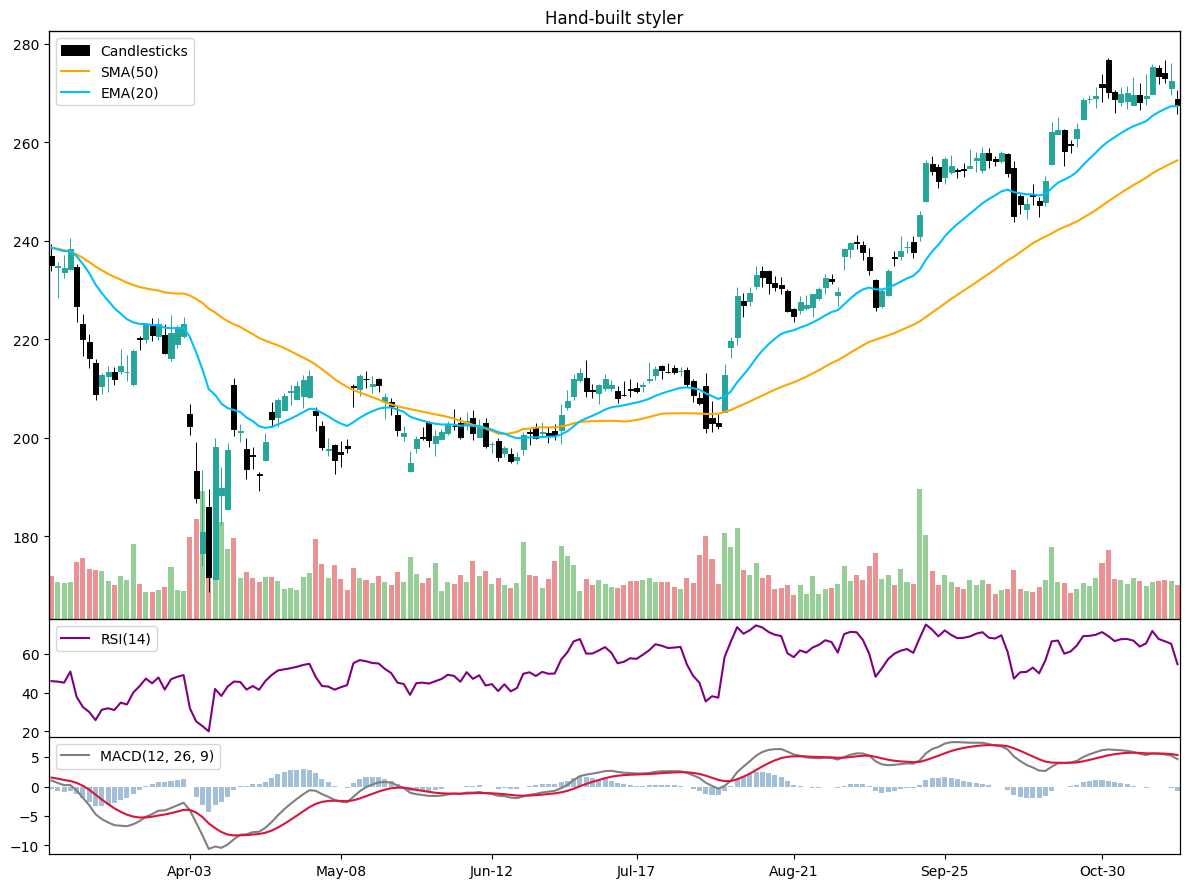

In [3]:
chart = Chart(prices, title="Hand-built styler", max_bars=180, style=styler)
chart.plot(Candlesticks(), SMA(50), EMA(20), Volume())
chart.pane("below").plot(RSI(14))
chart.pane("below").plot(MACD())
chart.show()

## Direct resolution

How `resolve_color` / `get_setting` see the settings.

In [4]:
(
    styler.resolve_color("sma-50"),       # prefix match on a per-instance label
    styler.resolve_color("SMA(50)"),      # repr-style labels normalize the same way
    styler.get_setting("candle.up", "color"),
    styler.resolve_color("unknown", fallback="~teal"),  # ~ snaps to the prop cycle
)

('#ffa500', '#ffa500', '#26a69a', '#1f77b4')

## Deriving a variant

`replace` is immutable-style: new styler, original untouched.

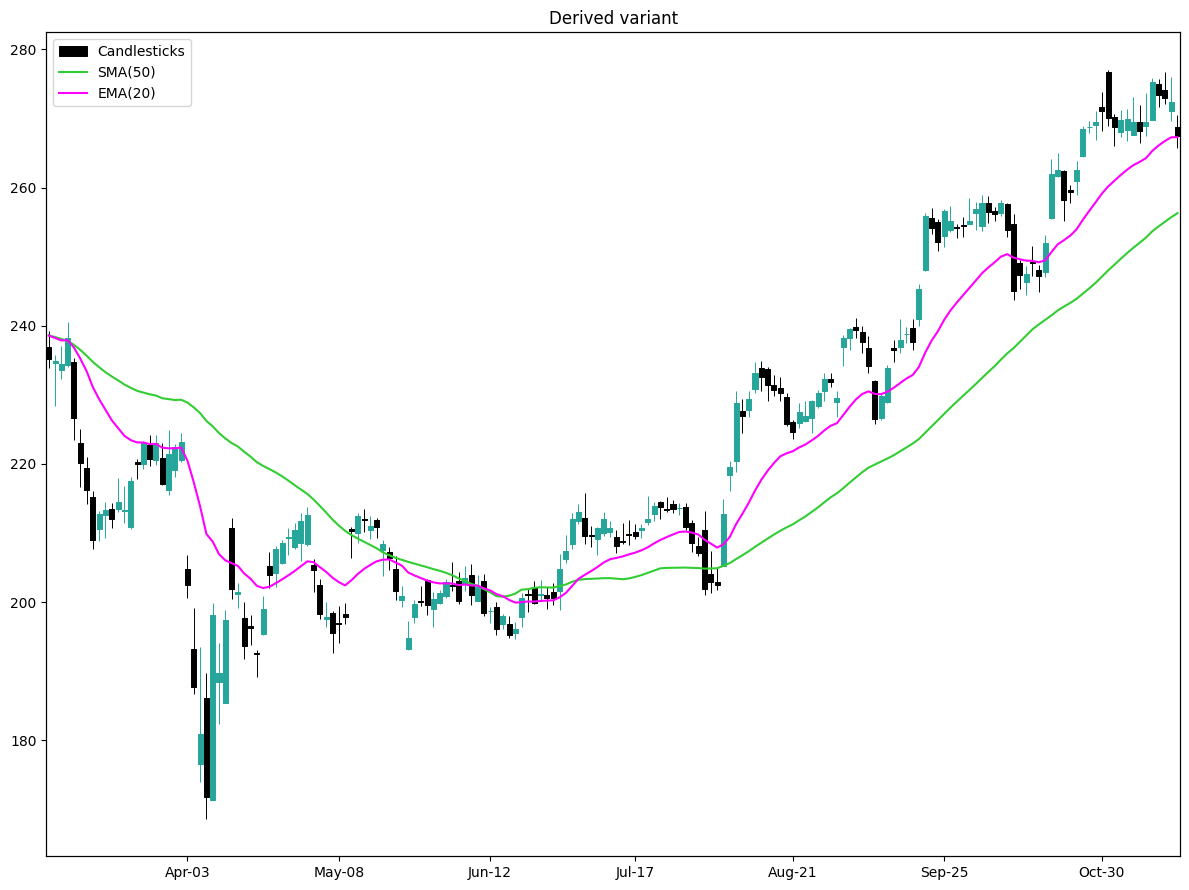

In [5]:
variant = styler.replace(overrides={"sma.color": "limegreen", "ema.color": "magenta"})
chart = Chart(prices, title="Derived variant", max_bars=180, style=variant)
chart.plot(Candlesticks(), SMA(50), EMA(20))
chart.show()